# M11.14 — Multi-event real-data validation

Comparación nominal emparejada de M10 y M11 en la cohorte real del notebook M10.13.
Predictor, preprocessing y Mondrian están congelados. No se optimiza nada con LVK.
**Conservative es el resultado principal; efficient se guarda como secundario.**
No se ejecutan barridos PSD/tiempo, ablations, ajustes ni diagnósticos de dominio.
Ejecutar por secciones. Este notebook se entrega sin ejecutar inferencia multi-evento.

Se conserva la lista de 14 candidatos M10, incluidos los cinco fallos históricos,
para registrar explícitamente elegibilidad y exclusiones. Los agregados usan sólo
pares M10/M11 completos del mismo evento y referencia. LVK es inferencia de referencia,
no ground truth; los intervalos conformales no son posteriores astrofísicos.

## 1. Imports y paths

In [1]:
from pathlib import Path
import sys, json, pickle, hashlib, urllib.request
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

root = next((p for p in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
             if (p / "src/paths.py").is_file()), None)
if root is None:
    raise RuntimeError("Abrir desde cbc_pe")
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from src.paths import resolve_project_root, resolve_data_root
from src.config import SimulationConfig
from src.processing import SignalProcessor
from src.models.network import SimpleCNN_ResidualDilated
from src.models.dataset import normalize_input_per_sample_per_detector_zscore
from src.real_data.catalog import get_event_detector_url
from src.real_data.gwosc_utils import read_gwosc_hdf5_as_pycbc_timeseries
from src.real_data.signal_processing import build_real_input_like_training, event_window_is_available_and_finite
from src.real_data.psd import select_valid_psd_window
from src.real_data.inference import predict_real_with_embeddings
from src.real_data.event_runner import classify_failure_reason
from src.conformal.selected_calibrators import apply_selected_calibrators
from src.evaluation.lvk import add_lvk_comparison_metrics

PROJECT_ROOT = resolve_project_root()
def read_json(path):
    return json.loads(Path(path).read_text())
def require(condition, message):
    if not condition:
        raise ValueError(message)
def small_file_hash(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

TRAIN_PATHS = {
    "M10": PROJECT_ROOT / "configs/experiments/train_500k_M10_inputzscore_resdilated_emb64_d124_bs256_seed123.json",
    "M11": PROJECT_ROOT / "configs/experiments/train_m11_final_G1_500k.json",
}
train_configs = {m: read_json(p) for m,p in TRAIN_PATHS.items()}
DATA_ROOT = resolve_data_root(config_data_root=train_configs["M11"]["data_root"])
LABELS = ["chirp_mass", "total_mass", "chi_eff"]
DETECTORS = ["H1", "L1", "V1"]
POLICIES = ["conservative", "efficient"]
CHECKPOINTS = {}
for m,cfg in train_configs.items():
    ds = cfg["dataset"]["dataset_id"]
    filename = f'{ds}_SimpleCNN_ResidualDilated_{cfg["outputs"]["checkpoint_tag"]}_MSELoss_seed123_checkpoint.pt'
    directory = DATA_ROOT / "models/checkpoints"
    candidates = [directory / ds / filename, directory / filename]
    CHECKPOINTS[m] = next((p for p in candidates if p.is_file()), candidates[0])
BUNDLE_PATHS = {
    "M10": DATA_ROOT / "results/mondrian_M10_final_baseline/selected_calibrators_frozen.pkl",
    "M11": DATA_ROOT / "results/M11_final_G1_500k/mondrian_m11_selected_calibrators_frozen.pkl",
}
M10_RESULTS = DATA_ROOT / "results" / train_configs["M10"]["dataset"]["dataset_id"] / "real_events_m10_500k_lvk_comparison"
EVENT_LIST_PATH = M10_RESULTS / "multi_event_all_catalog_candidates.csv"
HISTORICAL_FAILURES_PATH = M10_RESULTS / "multi_event_all_failed_events.csv"
LVK_PATH = DATA_ROOT / "lvk_references/GWTC-3-confident_detector_frame_reference_error_propagated.csv"
GEN_PATH = PROJECT_ROOT / "configs/generation/generate_500k_bbh_4s.json"
GWOSC_CACHE = DATA_ROOT / "gwosc_cache"
OUTPUT_DIR = DATA_ROOT / "results/M11_final_G1_500k/real_events/multi_event"
FIGURE_DIR = OUTPUT_DIR / "figures"
ANCHOR_DIR = DATA_ROOT / "results/M11_final_G1_500k/real_events/GW170814"
path_rows = [dict(role=role, model=m, path=str(p), exists=p.is_file())
             for role, paths in [("checkpoint", CHECKPOINTS), ("frozen bundle", BUNDLE_PATHS)]
             for m,p in paths.items()]
path_rows += [dict(role=role, model="shared", path=str(p), exists=p.is_file())
              for role,p in [("M10 cohort", EVENT_LIST_PATH), ("M10 exclusions", HISTORICAL_FAILURES_PATH),
                             ("LVK", LVK_PATH), ("generation config", GEN_PATH)]]
path_audit = pd.DataFrame(path_rows)
with pd.option_context("display.max_colwidth", None):
    display(path_audit)
require(path_audit.exists.all(), "Missing frozen inputs; inspect path table")
print("GWOSC cache:", GWOSC_CACHE, "Output:", OUTPUT_DIR)

/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/types/array.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal as _lal


,role,model,path,exists
0,checkpoint,M10,/data/vserrano/cbc_pe_data/models/checkpoints/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000_SimpleCNN_ResidualDilated_M10_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt,True
1,checkpoint,M11,/data/vserrano/cbc_pe_data/models/checkpoints/M11_final_G1_500k/M11_final_G1_500k_SimpleCNN_ResidualDilated_M11_final_G1_inputzscore_resdilated_emb64_d124_train400k_MSELoss_seed123_checkpoint.pt,True
2,frozen bundle,M10,/data/vserrano/cbc_pe_data/results/mondrian_M10_final_baseline/selected_calibrators_frozen.pkl,True
3,frozen bundle,M11,/data/vserrano/cbc_pe_data/results/M11_final_G1_500k/mondrian_m11_selected_calibrators_frozen.pkl,True
4,M10 cohort,shared,/data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/multi_event_all_catalog_candidates.csv,True
5,M10 exclusions,shared,/data/vserrano/cbc_pe_data/results/bbh_processed_4s_seobnrv4opt_snr10-25_n500_000/real_events_m10_500k_lvk_comparison/multi_event_all_failed_events.csv,True
6,LVK,shared,/data/vserrano/cbc_pe_data/lvk_references/GWTC-3-confident_detector_frame_reference_error_propagated.csv,True
7,generation config,shared,/afs/ciemat.es/user/v/vserrano/Desktop/gw/Gravitational-Waves-Lab/cbc_pe/configs/generation/generate_500k_bbh_4s.json,True


GWOSC cache: /data/vserrano/cbc_pe_data/gwosc_cache Output: /data/vserrano/cbc_pe_data/results/M11_final_G1_500k/real_events/multi_event


## 2. Cohorte heredada M10

Se lee el CSV congelado, sin consultar un catálogo actualizado ni repetir filtros
por masas/SNR. M10 procesó nueve de estos 14 candidatos; cinco fallaron por NaN/Inf
en V1. Se conservan los motivos históricos como contexto y se registra el estado de
esta ejecución por separado. Ningún fallo histórico se repara ni se oculta.

**GW170814 no pertenece a esta cohorte GWTC-3.** No se añade a los agregados.
Su referencia sigue siendo exactamente `Overall_posterior` de GWTC-1
[LIGO-P1800370-v5](https://dcc.ligo.org/LIGO-P1800370/public), archivo
`GW170814_GWTC-1.hdf5`, tal como M11.13 (masas ya detector-frame, cuantiles 5/50/95).
Sus resultados guardados se muestran sólo como ancla separada cuando existen.

In [2]:
events = pd.read_csv(EVENT_LIST_PATH)
require(not events.event.duplicated().any(), "Duplicate cohort events")
require(len(events) == 14, "M10 frozen candidate cohort changed")
historical_failures = pd.read_csv(HISTORICAL_FAILURES_PATH)
reasons = historical_failures.set_index("event")["error"]
events["historical_failure"] = events.event.map(reasons).fillna("")
events["processing_status"] = "pending"
events["reference_source"] = str(LVK_PATH)
display(events[["event", "gps_time", "detectors", "catalog", "reference_source",
                "processing_status", "historical_failure"]])
anchor_reference_path = ANCHOR_DIR / "lvk_detector_frame_reference.csv"
anchor_predictions_path = ANCHOR_DIR / "predictions.csv"
if anchor_reference_path.is_file():
    print("GW170814 reference from M11.13, outside aggregate cohort:")
    display(pd.read_csv(anchor_reference_path))
else:
    print("GW170814: consult M11.13; no saved reference table here. No GWTC-3 substitution.")

,event,gps_time,detectors,catalog,reference_source,processing_status,historical_failure
0,GW200202_154313,1.264693e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,
1,GW191129_134029,1.259070e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,Invalid event window: V1: event processing win...
2,GW200316_215756,1.268431e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,
3,GW200225_060421,1.266646e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,Invalid event window: V1: event processing win...
4,GW191215_223052,1.260484e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,
5,GW200129_065458,1.264316e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,
6,GW200311_115853,1.267963e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,
7,GW200208_130117,1.265202e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,
8,GW200224_222234,1.266618e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,
9,GW200219_094415,1.266141e+09,"H1,L1,V1",GWTC-3-confident,/data/vserrano/cbc_pe_data/lvk_references/GWTC...,pending,


GW170814 reference from M11.13, outside aggregate cohort:


,event,gps_time,catalog,detectors,reference_type,chirp_mass_lvk,chirp_mass_lvk_lower,chirp_mass_lvk_upper,total_mass_lvk,total_mass_lvk_lower,total_mass_lvk_upper,chi_eff_lvk,chi_eff_lvk_lower,chi_eff_lvk_upper
0,GW170814,1.186742e+09,GWTC-1-confident,"H1,L1,V1",Overall_posterior,27.052104,25.932833,28.285117,62.764768,60.17218,65.947365,0.067326,-0.048331,0.184569


## 3. Contratos congelados y carga para inferencia

Misma entrada real para ambos modelos: HLV, 4096 Hz, 4 s, contexto 1664 muestras/lado;
PSD whitening 0.5 s Hann, highpass 30/lowpass 512 Hz, FIR 256 beta 5,
remove corrupted y crop. Se preserva el acondicionamiento PSD histórico en estimación
y en `SignalProcessor`. Z-score una vez, después del crop, ε=1e−6.

Checks ligeros de compatibilidad al cargar; no se repiten test sintético, hashes de
artefactos grandes ni validación histórica de calibradores. Los manifests de export
ya contienen esa validación. Masas detector-frame (Msun), chi_eff adimensional.

In [3]:
gen_cfg = read_json(GEN_PATH)
sim_config = SimulationConfig(duration=4.0, processing_context_start_samples=1664,
                              processing_context_end_samples=1664)
processor = SignalProcessor(config=sim_config, **gen_cfg["signal_processor"])
require(not processor.apply_standardization, "Z-score must be applied once outside processor")
NOMINAL_PSD = (-1024.0, -640.0)
CENTER_OFFSET = 0.0
PSD_SEGMENT_DURATION = 8.0
models, scalers, calibrators, bundle_provenance = {}, {}, {}, {}
for m,path in CHECKPOINTS.items():
    checkpoint = torch.load(path, map_location="cpu")
    config = checkpoint["model_config"]
    require(config["label_names"] == LABELS and config["signal_length"] == 16384
            and config["n_detectors"] == 3, f"Model contract {m}")
    model = SimpleCNN_ResidualDilated(**config["model_kwargs"])
    model.load_state_dict(checkpoint["model_state_dict"])
    models[m] = model.cpu().eval()
    scalers[m] = tuple(np.asarray(checkpoint[k], dtype=np.float64) for k in ("y_mean", "y_std"))
    with BUNDLE_PATHS[m].open("rb") as f:
        bundle = pickle.load(f)
    metadata = bundle["metadata"]
    require(metadata["label_names"] == LABELS and metadata["calibration_space"] == "standardized",
            f"Conformal label/frame contract {m}")
    require(Path(metadata["checkpoint_path"]).name == path.name, f"Checkpoint identity {m}")
    require(all(np.array_equal(metadata[k], a) for k,a in zip(("y_mean", "y_std"), scalers[m])),
            f"Scaler compatibility {m}")
    require(set(bundle["calibrators"]) == {(p,l) for p in POLICIES for l in LABELS},
            f"Expected frozen six systems {m}")
    calibrators[m] = bundle["calibrators"]
    manifest_path = BUNDLE_PATHS[m].with_name(BUNDLE_PATHS[m].stem + "_provenance.json")
    manifest = read_json(manifest_path)
    require(manifest["accepted"] and manifest["failed_checks"] == 0, f"Unaccepted bundle {m}")
    bundle_provenance[m] = dict(bundle_path=str(BUNDLE_PATHS[m]),
        recorded_sha256=manifest["bundle_sha256"], metadata=metadata,
        validation_manifest=str(manifest_path))
    del checkpoint, bundle
contracts = pd.DataFrame([dict(model=m,
    training_domain="analytical PSD Gaussian / historical M10" if m=="M10" else "empirical PSD Gaussian G1",
    preprocessing="HLV 4096Hz/4s; PSD whitening; 30–512Hz; context1664; crop",
    normalization="per sample/detector zscore once, eps=1e-6",
    checkpoint=str(CHECKPOINTS[m]), mondrian_bundle=str(BUNDLE_PATHS[m])) for m in models])
display(contracts)

,model,training_domain,preprocessing,normalization,checkpoint,mondrian_bundle
0,M10,analytical PSD Gaussian / historical M10,HLV 4096Hz/4s; PSD whitening; 30–512Hz; contex...,"per sample/detector zscore once, eps=1e-6",/data/vserrano/cbc_pe_data/models/checkpoints/...,/data/vserrano/cbc_pe_data/results/mondrian_M1...
1,M11,empirical PSD Gaussian G1,HLV 4096Hz/4s; PSD whitening; 30–512Hz; contex...,"per sample/detector zscore once, eps=1e-6",/data/vserrano/cbc_pe_data/models/checkpoints/...,/data/vserrano/cbc_pe_data/results/M11_final_G...


## 4. Referencias LVK congeladas

Para los 14 eventos se reutiliza el CSV final del notebook M10.13: summaries oficiales
GWOSC GWTC-3, convertidos allí a detector frame con M_detector=(1+z) M_source y
propagación de primer orden de errores de masa/redshift. No se convierten de nuevo.
Se conserva la fuente histórica y se declara la aproximación: estos límites no se
recalculan aquí desde muestras conjuntas del posterior. No se inicia una nueva
búsqueda/descarga de posteriores de toda la cohorte. GW170814, cuya referencia oficial
por muestras ya está validada, permanece separado como se indicó arriba.

`lvk_central` distingue el valor central de catálogo de una mediana calculada aquí.
Los límites disponibles son los usados por M10; LVK no se trata como verdad conocida.

In [4]:
lvk_reference = pd.read_csv(LVK_PATH)
require(not lvk_reference.event.duplicated().any(), "Duplicate LVK event reference")
lvk_reference = lvk_reference.set_index("event")

## 5. Única ruta nominal por evento

Se congela la ventana solicitada por el runner multi-evento M10: **(-1024,-640) s**,
centro=GPS+0, PSD Welch de segmentos de 8 s. Fue también la ventana efectiva de los
nueve eventos procesados. Si no es válida se registra el fallo, sin probar alternativas;
esto evita repetir las listas de fallback/robustness. No interviene LVK en esta regla.
Strain se prepara una sola vez y se comparte entre ambos modelos. Archivos existentes
se reutilizan; los corruptos producen error, nunca reparación automática.

In [5]:
def prepare_nominal(event, gps, available_detectors, catalog):
    require(set(str(available_detectors).split(",")) >= set(DETECTORS), "missing_required_detectors")
    raw, sources = {}, []
    for detector in DETECTORS:
        url = get_event_detector_url(event_name=event, detector=detector, catalog=catalog, sample_rate=4096)
        require(url is not None, f"missing_url: {event}/{detector}")
        filename = url.rsplit("/", 1)[-1]
        locations = [GWOSC_CACHE / filename, GWOSC_CACHE / "notebooks_root" / filename,
                     GWOSC_CACHE / "m11" / filename]
        local = next((p for p in locations if p.is_file()), locations[0])
        if not local.is_file():
            GWOSC_CACHE.mkdir(parents=True, exist_ok=True)
            urllib.request.urlretrieve(url, local)
        strain = read_gwosc_hdf5_as_pycbc_timeseries(local)
        require(float(strain.sample_rate) == 4096, f"sample_rate: {detector}")
        raw[detector] = strain
        sources.append(dict(detector=detector, url=url, cached_file=str(local)))
    center = float(gps) + CENTER_OFFSET
    ok, reason = event_window_is_available_and_finite(raw, center, final_duration=4.0,
        context_start_samples=1664, context_end_samples=1664, sampling_frequency=4096)
    require(ok, f"Invalid event window: {reason}")
    selected = select_valid_psd_window(raw, center, preferred_window=NOMINAL_PSD, candidate_windows=())
    X_pre, _, _, _, meta = build_real_input_like_training(raw_strains=raw, detectors=DETECTORS,
        center_time=center, processor=processor, expected_detector_order=DETECTORS,
        final_duration=4.0, final_length=16384, processing_length=19712,
        context_start_samples=1664, context_end_samples=1664, sampling_frequency=4096,
        psd_delta_f=4096/19712, psd_target_flength=9857,
        psd_start_offset=selected[0], psd_end_offset=selected[1], psd_segment_duration=8.0)
    X = normalize_input_per_sample_per_detector_zscore(X_pre[0], eps=1e-6)[None, :, :]
    require(X.shape == (1,3,16384) and np.isfinite(X).all(), "Invalid nominal input")
    diagnostics = pd.DataFrame([dict(event=event, detector=detector,
        pre_zscore_std=float(X_pre[0,j].std()),
        pre_zscore_rms=float(np.sqrt(np.mean(X_pre[0,j].astype(float)**2))),
        post_zscore_mean=float(X[0,j].mean()), post_zscore_std=float(X[0,j].std()),
        finite=bool(np.isfinite(X_pre[0,j]).all() and np.isfinite(X[0,j]).all()))
        for j,detector in enumerate(DETECTORS)])
    return X, diagnostics, dict(event=event, gps=float(gps), sources=sources,
        psd_window=list(selected), center_offset=CENTER_OFFSET, zscore_count=1, processing=meta)


def infer_pair(event, X):
    points, intervals = [], []
    for m,model in models.items():
        mean, std = scalers[m]
        pred_std, _, embedding = predict_real_with_embeddings(model, X, "cpu", mean, std)
        pred_phys = pred_std * std[None,:] + mean[None,:]
        require(np.isfinite(pred_phys).all() and np.isfinite(embedding).all(), f"Nonfinite inference {m}")
        points.append(pd.DataFrame(dict(event=event, model=m, label=LABELS,
            prediction=pred_phys[0], frame=["detector", "detector", "dimensionless"])))
        interval = apply_selected_calibrators(calibrators[m], pred_std, LABELS,
            target_embedding=embedding, event_name=event)
        j = interval.label_index.to_numpy(dtype=int)
        interval["model"] = m
        interval["prediction"] = interval.pred_std.to_numpy()*std[j]+mean[j]
        interval["lower"] = interval.lower_std.to_numpy()*std[j]+mean[j]
        interval["upper"] = interval.upper_std.to_numpy()*std[j]+mean[j]
        interval["width"] = interval.upper-interval.lower
        interval = interval.rename(columns={"final_policy": "policy"})
        require(np.isfinite(interval[["prediction", "lower", "upper", "width"]]).all().all(), "Invalid intervals")
        intervals.append(interval[["event", "model", "policy", "label", "prediction", "lower", "upper", "width",
                                   "taxonomy_mode", "interval_mode", "n_bins", "mondrian_bin"]])
    return pd.concat(points, ignore_index=True), pd.concat(intervals, ignore_index=True)


def compare_lvk(intervals, reference):
    frames = []
    for label in LABELS:
        table = intervals[intervals.label == label].copy()
        for suffix, column in [("", "prediction"), ("_lower", "lower"), ("_upper", "upper")]:
            table[f"{label}_cnn{suffix}"] = table[column]
            table[f"{label}_lvk{suffix}"] = float(reference[f"{label}_lvk{suffix}"])
        table = add_lvk_comparison_metrics(table, labels=[label])
        for target,suffix in [("signed_discrepancy", "delta_cnn_minus_lvk"),
            ("normalized_discrepancy", "normalized_delta_lvk"), ("cnn_point_inside_lvk", "cnn_point_inside_lvk"),
            ("overlap", "interval_overlap"), ("overlap_fraction_lvk", "interval_overlap_fraction_lvk"),
            ("lvk_central_inside_mondrian", "lvk_median_inside_cnn")]:
            table[target] = table[f"{label}_{suffix}"]
        table["absolute_discrepancy"] = table.signed_discrepancy.abs()
        table["intervals_overlap"] = table.overlap > 0
        table["lvk_central"] = float(reference[f"{label}_lvk"])
        table["lvk_lower"] = float(reference[f"{label}_lvk_lower"])
        table["lvk_upper"] = float(reference[f"{label}_lvk_upper"])
        table["reference_type"] = "GWTC-3 catalog summary; detector-frame error propagation (M10)"
        metrics = ["lvk_central", "lvk_lower", "lvk_upper", "reference_type", "signed_discrepancy",
            "absolute_discrepancy", "normalized_discrepancy", "cnn_point_inside_lvk", "overlap",
            "overlap_fraction_lvk", "intervals_overlap", "lvk_central_inside_mondrian"]
        frames.append(table[[*intervals.columns, *metrics]])
    return pd.concat(frames, ignore_index=True)

## 6. Inferencia y guardado incremental

Esta celda procesa la cohorte; **no se ejecuta durante la construcción del notebook**.
Cada evento produce un par completo M10/M11 o se registra como excluido. Errores de
referencia/datos se registran sin reparar; errores de modelo/conformal se registran
y detienen la ejecución para revisión. Se guardan CSV acumulativos y provenance
tras cada evento, incluyendo fallos. Reiniciar esta celda reinicia la ejecución;
los CSV incrementales protegen resultados parciales, no implementan auto-resume.

In [6]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
point_frames, interval_frames, comparison_frames, scale_frames = [], [], [], []
skipped_rows, processed_provenance = [], []
events["processing_status"] = "pending"


def save_incremental():
    frames = {"event_predictions": point_frames, "mondrian_intervals": interval_frames,
              "lvk_comparison": comparison_frames, "preprocessing_summary": scale_frames}
    for name, items in frames.items():
        if items:
            pd.concat(items, ignore_index=True).to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
        else:
            pd.DataFrame(columns=["event", "model", "label"]).to_csv(OUTPUT_DIR / f"{name}.csv", index=False)
    pd.DataFrame(skipped_rows, columns=["event", "stage", "reason", "error"]).to_csv(
        OUTPUT_DIR / "skipped_events.csv", index=False)
    events.to_csv(OUTPUT_DIR / "event_status.csv", index=False)
    provenance = dict(cohort_path=str(EVENT_LIST_PATH), cohort_sha256=small_file_hash(EVENT_LIST_PATH),
        lvk_path=str(LVK_PATH), lvk_sha256=small_file_hash(LVK_PATH),
        nominal_policy=dict(psd_window=NOMINAL_PSD, center_offset=CENTER_OFFSET,
                            psd_segment_duration=PSD_SEGMENT_DURATION, fallback_windows=[], zscore_eps=1e-6),
        preprocessing=processor.metadata(), models=bundle_provenance,
        checkpoints={m:str(p) for m,p in CHECKPOINTS.items()}, primary_policy="conservative",
        frame="detector-frame masses Msun; chi_eff dimensionless", events=processed_provenance,
        skipped=skipped_rows, status_counts=events.processing_status.value_counts().to_dict(),
        gw170814_role="separate M11.13 GWTC-1 posterior anchor, excluded from cohort aggregates",
        code_sources={str(p):small_file_hash(p) for p in [
            PROJECT_ROOT / "notebooks/m11/M11_14_real_events_lvk_comparison.ipynb", GEN_PATH]},
        versions=dict(python=sys.version, numpy=np.__version__, torch=torch.__version__))
    (OUTPUT_DIR / "provenance.json").write_text(json.dumps(provenance, indent=2), encoding="utf-8")

for index,row in events.iterrows():
    event = row.event
    print(event)
    stage = "reference"
    try:
        require(event in lvk_reference.index, "Missing LVK reference")
        reference = lvk_reference.loc[event]
        require(reference["catalog"] == row["catalog"], "LVK catalog mismatch")
        for label in LABELS:
            values = [float(reference[f"{label}_lvk{s}"]) for s in ("_lower", "", "_upper")]
            require(np.isfinite(values).all() and values[0] < values[1] < values[2], "Invalid LVK bounds")
        stage = "data"
        X, diagnostics, meta = prepare_nominal(event, row.gps_time, row.detectors, row["catalog"])
        stage = "inference_and_frozen_intervals"
        points, intervals = infer_pair(event, X)
        comparison = compare_lvk(intervals, reference)
        point_frames.append(points)
        interval_frames.append(intervals)
        comparison_frames.append(comparison)
        scale_frames.append(diagnostics)
        processed_provenance.append(meta)
        events.loc[index, "processing_status"] = "success"
        del X
    except Exception as error:
        events.loc[index, "processing_status"] = "skipped" if stage in ("data", "reference") else "error"
        skipped_rows.append(dict(event=event, stage=stage, reason=classify_failure_reason(str(error)),
                                 error=f"{type(error).__name__}: {error}"))
        if stage not in ("data", "reference"):
            save_incremental()
            raise
        print("Skipped:", skipped_rows[-1])
    save_incremental()
display(events[["event", "processing_status", "historical_failure"]])

GW200202_154313


/afs/ciemat.es/user/v/vserrano/miniconda3/envs/gw-env/lib/python3.10/site-packages/pycbc/waveform/plugin.py:99: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


GW191129_134029
Skipped: {'event': 'GW191129_134029', 'stage': 'data', 'reason': 'nonfinite_event_window', 'error': 'ValueError: Invalid event window: V1: event processing window contains NaN/Inf'}
GW200316_215756
GW200225_060421
Skipped: {'event': 'GW200225_060421', 'stage': 'data', 'reason': 'nonfinite_event_window', 'error': 'ValueError: Invalid event window: V1: event processing window contains NaN/Inf'}
GW191215_223052
GW200129_065458
GW200311_115853
GW200208_130117
GW200224_222234
GW200219_094415
GW200128_022011
Skipped: {'event': 'GW200128_022011', 'stage': 'data', 'reason': 'nonfinite_event_window', 'error': 'ValueError: Invalid event window: V1: event processing window contains NaN/Inf'}
GW191222_033537
Skipped: {'event': 'GW191222_033537', 'stage': 'data', 'reason': 'nonfinite_event_window', 'error': 'ValueError: Invalid event window: V1: event processing window contains NaN/Inf'}
GW191109_010717
Skipped: {'event': 'GW191109_010717', 'stage': 'data', 'reason': 'nonfinite_even

,event,processing_status,historical_failure
0,GW200202_154313,success,
1,GW191129_134029,skipped,Invalid event window: V1: event processing win...
2,GW200316_215756,success,
3,GW200225_060421,skipped,Invalid event window: V1: event processing win...
4,GW191215_223052,success,
5,GW200129_065458,success,
6,GW200311_115853,success,
7,GW200208_130117,success,
8,GW200224_222234,success,
9,GW200219_094415,success,


## 7. Tablas agregadas y por evento — conservative

Comparación pareada sobre eventos válidos para ambos modelos. La fracción “M11 más
cerca” usa desigualdad estricta; se muestran además empates y empeoramientos.
`fraction_intervals_overlapped` cuenta intersecciones de longitud positiva y
`median_overlap_fraction_lvk` resume la fracción de longitud del intervalo LVK
solapada. Ninguna de estas cantidades es cobertura conformal sobre verdad conocida.
No se añaden tests estadísticos a una cohorte pequeña y seleccionada.

In [7]:
aggregate_rows = []
per_event = pd.DataFrame()
if comparison_frames:
    comparisons = pd.concat(comparison_frames, ignore_index=True)
    main = comparisons[comparisons.policy == "conservative"].copy()
    keys = ["event", "label", "lvk_central", "lvk_lower", "lvk_upper"]
    fields = ["prediction", "absolute_discrepancy", "lower", "upper", "width", "overlap",
              "overlap_fraction_lvk", "intervals_overlap"]
    per_event = main[main.model == "M10"][keys+fields].merge(
        main[main.model == "M11"][keys+fields], on=keys, suffixes=("_M10", "_M11"), validate="one_to_one")
    require(len(per_event) == len(main)//2, "Incomplete paired comparison")
    for label, table in per_event.groupby("label", sort=False):
        a, b = table.absolute_discrepancy_M10, table.absolute_discrepancy_M11
        result = dict(label=label, n_valid_events=len(table),
            fraction_M11_closer=float((b<a).mean()), fraction_equal=float((b==a).mean()),
            fraction_M11_further=float((b>a).mean()))
        for m in ("M10", "M11"):
            result[f"median_absolute_discrepancy_{m}"] = float(table[f"absolute_discrepancy_{m}"].median())
            result[f"median_mondrian_width_{m}"] = float(table[f"width_{m}"].median())
            result[f"fraction_intervals_overlapped_{m}"] = float(table[f"intervals_overlap_{m}"].mean())
            result[f"median_overlap_fraction_lvk_{m}"] = float(table[f"overlap_fraction_lvk_{m}"].median())
        aggregate_rows.append(result)
else:
    print("No valid paired events. Review skipped_events.csv; do not infer agreement.")
aggregate_summary = pd.DataFrame(aggregate_rows, columns=["label", "n_valid_events",
    "fraction_M11_closer", "fraction_equal", "fraction_M11_further",
    "median_absolute_discrepancy_M10", "median_mondrian_width_M10", "fraction_intervals_overlapped_M10",
    "median_overlap_fraction_lvk_M10", "median_absolute_discrepancy_M11", "median_mondrian_width_M11",
    "fraction_intervals_overlapped_M11", "median_overlap_fraction_lvk_M11"])
display(aggregate_summary)
display(per_event)
aggregate_summary.to_csv(OUTPUT_DIR / "aggregate_summary.csv", index=False)
per_event.to_csv(OUTPUT_DIR / "per_event_comparison.csv", index=False)

,label,n_valid_events,fraction_M11_closer,fraction_equal,fraction_M11_further,median_absolute_discrepancy_M10,median_mondrian_width_M10,fraction_intervals_overlapped_M10,median_overlap_fraction_lvk_M10,median_absolute_discrepancy_M11,median_mondrian_width_M11,fraction_intervals_overlapped_M11,median_overlap_fraction_lvk_M11
0,chirp_mass,9,0.666667,0.0,0.333333,2.453911,16.720632,0.888889,0.678606,1.987950,17.083339,1.000000,1.000000
1,total_mass,9,0.777778,0.0,0.222222,6.351077,25.056439,0.888889,0.920607,3.873451,27.696938,0.888889,0.849341
2,chi_eff,9,0.888889,0.0,0.111111,0.307677,0.594867,1.000000,0.637699,0.087100,0.608739,1.000000,0.990113


,event,label,lvk_central,lvk_lower,lvk_upper,prediction_M10,absolute_discrepancy_M10,lower_M10,upper_M10,width_M10,...,overlap_fraction_lvk_M10,intervals_overlap_M10,prediction_M11,absolute_discrepancy_M11,lower_M11,upper_M11,width_M11,overlap_M11,overlap_fraction_lvk_M11,intervals_overlap_M11
0,GW200202_154313,chirp_mass,8.1641,7.851028,8.508955,10.618011,2.453911,4.689821,16.465409,11.775588,...,1.000000,True,15.163832,6.999732,-3.395287,34.151132,37.546419,0.657927,1.000000,True
1,GW200202_154313,total_mass,19.1622,18.261373,21.172804,27.853656,8.691456,14.761179,36.067010,21.305831,...,1.000000,True,39.871470,20.709270,25.348115,50.149764,24.801649,0.000000,0.000000,False
2,GW200202_154313,chi_eff,0.0400,-0.020000,0.170000,0.433547,0.393547,0.164185,0.702909,0.538724,...,0.030603,True,0.166536,0.126536,-0.303083,0.636155,0.939238,0.190000,1.000000,True
3,GW200316_215756,chirp_mass,10.6750,9.705340,11.705602,12.507020,1.832020,0.550722,23.216379,22.665657,...,1.000000,True,13.909145,3.234145,-4.649974,32.896446,37.546419,2.000262,1.000000,True
4,GW200316_215756,total_mass,25.8640,22.892466,34.810232,32.079116,6.215116,18.986640,40.292471,21.305831,...,1.000000,True,35.095554,9.231554,20.572199,45.373848,24.801649,11.917767,1.000000,True
5,GW200316_215756,chi_eff,0.1300,0.030000,0.400000,0.071046,0.058954,-0.226388,0.368479,0.594867,...,0.914809,True,0.059093,0.070907,-0.278156,0.396342,0.674498,0.366342,0.990113,True
6,GW191215_223052,chirp_mass,24.8400,21.389956,28.653471,16.529647,8.310353,12.685882,19.973568,7.287686,...,0.000000,False,23.218558,1.621442,16.539890,29.959388,13.419498,7.263515,1.000000,True
7,GW191215_223052,total_mass,58.4550,50.061796,67.558827,40.197370,18.257630,27.104894,48.410725,21.305831,...,0.000000,False,54.644449,3.810551,40.121094,64.922743,24.801649,14.860946,0.849341,True
8,GW191215_223052,chi_eff,-0.0400,-0.250000,0.130000,-0.483656,0.443656,-0.762184,-0.205128,0.557055,...,0.118083,True,-0.377585,0.337585,-0.714834,-0.040336,0.674498,0.209664,0.551747,True
9,GW200129_065458,chirp_mass,32.0960,28.780730,34.922674,30.129896,1.966104,24.201705,35.977294,11.775588,...,1.000000,True,31.241331,0.854669,22.745788,39.829127,17.083339,6.141943,1.000000,True


## 8. Figuras finales — sólo conservative; tres figuras con panel por label

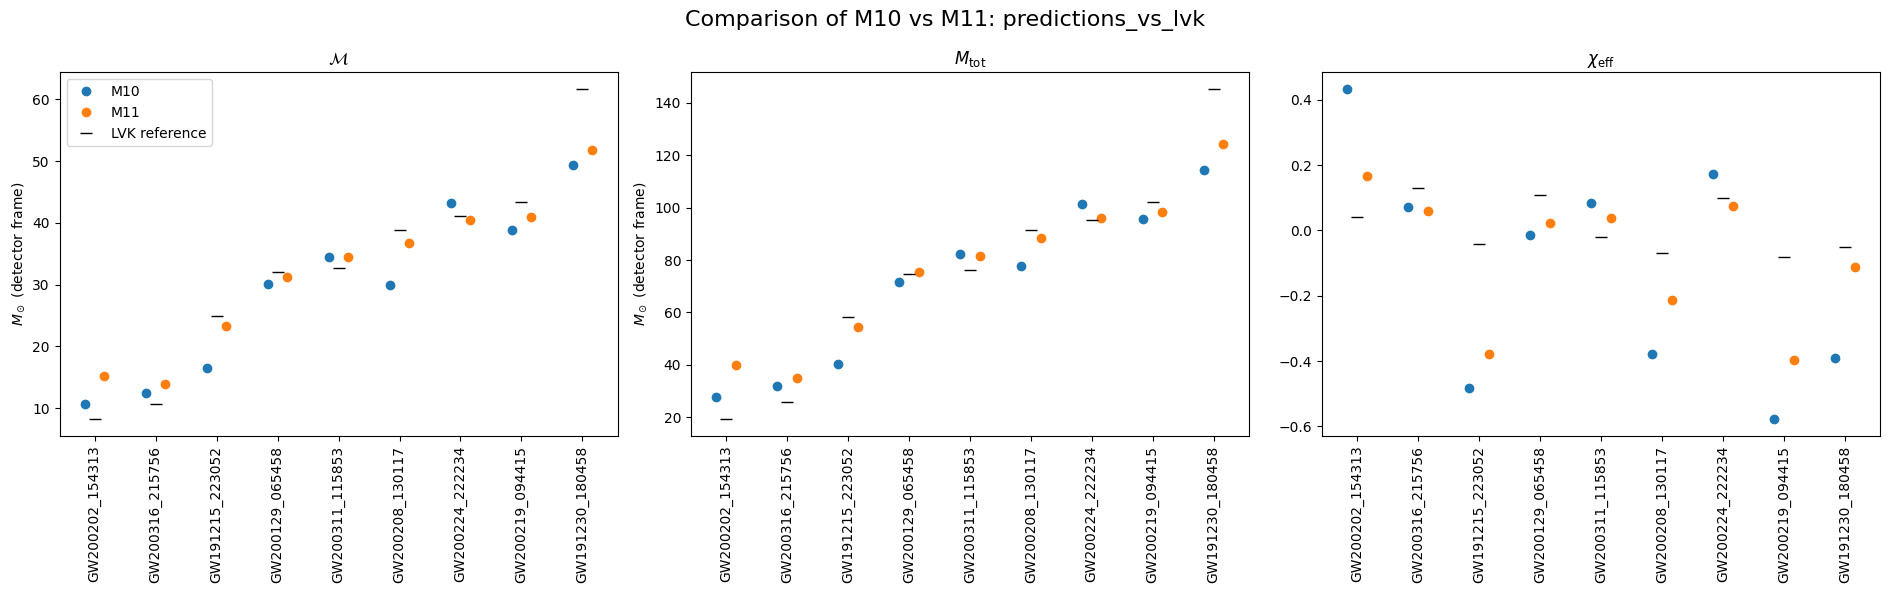

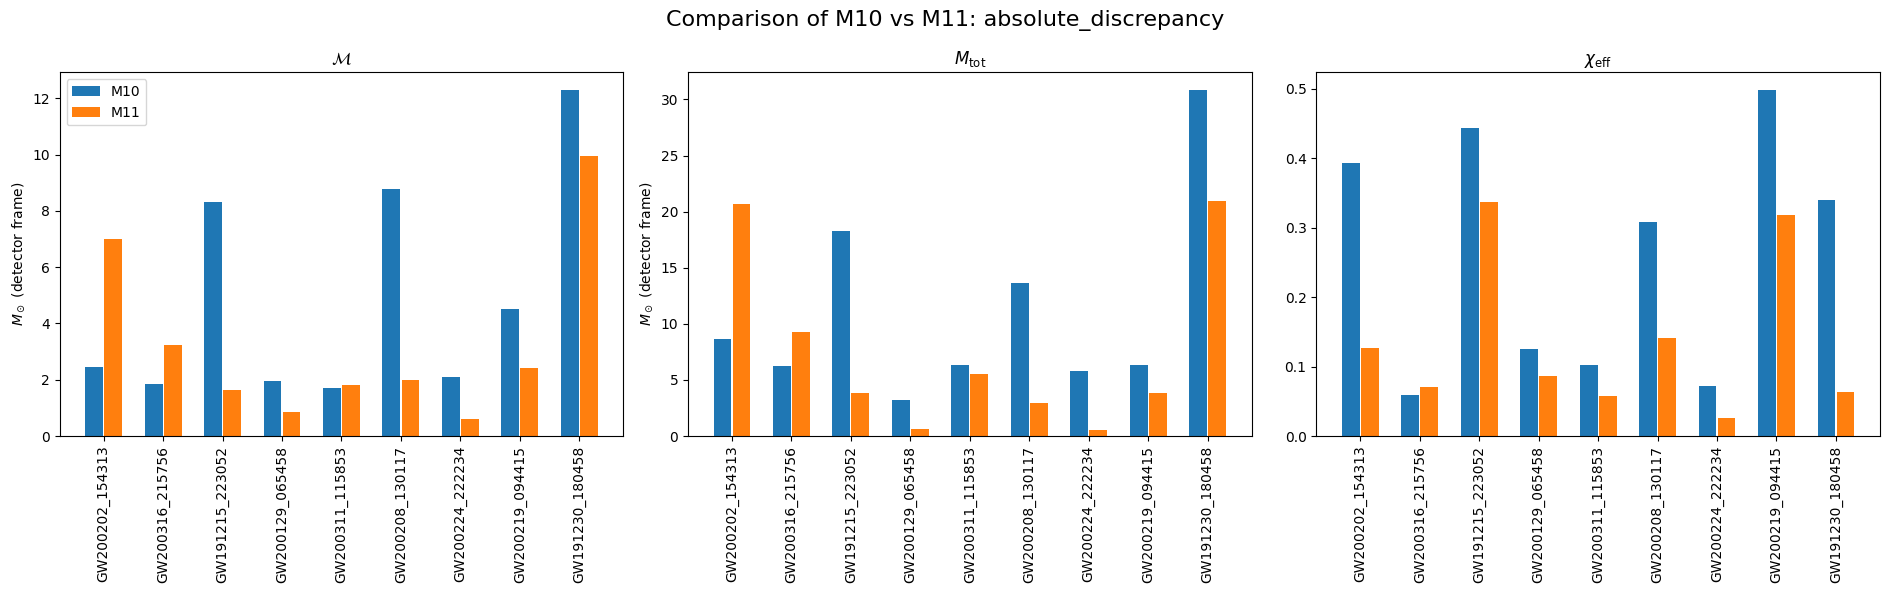

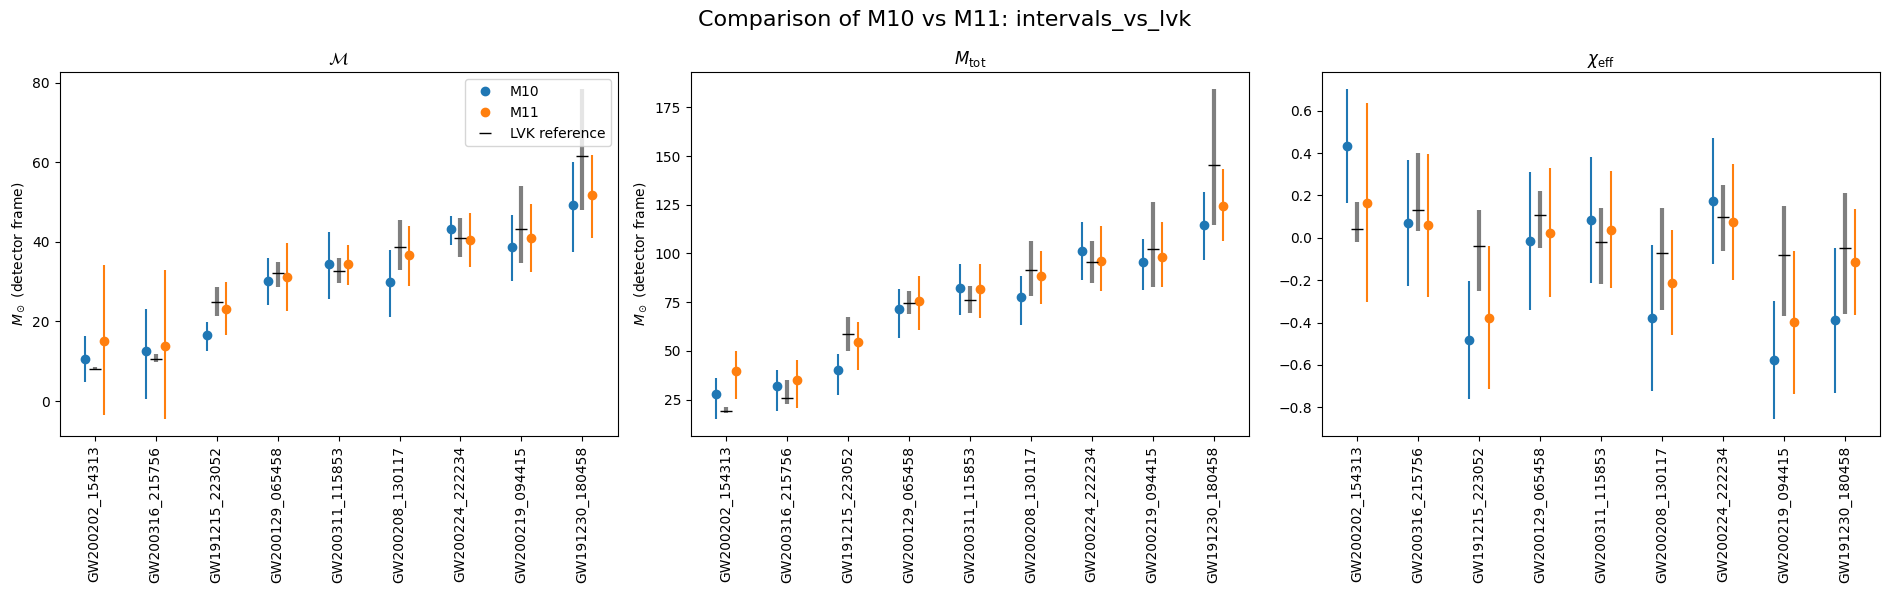

In [18]:
nice_labels = {"chirp_mass": r"$\mathcal{M}$", "total_mass": r"$M_{\mathrm{tot}}$", "chi_eff": r"$\chi_\mathrm{eff}$"}
if not per_event.empty:
    FIGURE_DIR.mkdir(parents=True, exist_ok=True)
    for kind in ("predictions_vs_lvk", "absolute_discrepancy", "intervals_vs_lvk"):
        fig, axes = plt.subplots(1,3,figsize=(19,6))
        fig.suptitle(f"Comparison of M10 vs M11: {kind}", fontsize=16)
        for ax,label in zip(axes,LABELS):
            table = per_event[per_event.label == label].reset_index(drop=True)
            x = np.arange(len(table))
            for m, shift, color in [("M10", -.16, "C0"), ("M11", .16, "C1")]:
                if kind == "absolute_discrepancy":
                    ax.bar(x+shift, table[f"absolute_discrepancy_{m}"], width=.3, label=m, color=color)
                else:
                    ax.plot(x+shift, table[f"prediction_{m}"], "o", label=m, color=color)
                    if kind == "intervals_vs_lvk":
                        ax.vlines(x+shift, table[f"lower_{m}"], table[f"upper_{m}"], color=color)
            if kind != "absolute_discrepancy":
                ax.plot(x, table.lvk_central, "k_", markersize=9, label="LVK reference")
                if kind == "intervals_vs_lvk":
                    ax.vlines(x, table.lvk_lower, table.lvk_upper, color="black", linewidth=3, alpha=.5)
            ax.set_xticks(x)
            ax.set_xticklabels(table.event, rotation=90)
            ax.set(title=nice_labels.get(label, label), ylabel=fr"$M_\odot$ (detector frame)" if label != "chi_eff" else "")
        axes[0].legend()
        fig.tight_layout()
        fig.savefig(FIGURE_DIR / f"{kind}.png", dpi=160, bbox_inches="tight")
        plt.show()

## 9. Summary by label — completar tras ejecutar

| Label | M11 mejora / iguala / empeora frente a M10 | ¿Generaliza GW170814? | Incertidumbre |
|---|---|---|---|
| chirp_mass | [n, discrepancias y fracciones pareadas] | [comparar con M11.13, sin añadirlo a la cohorte] | [ancho y overlap] |
| total_mass | [n, discrepancias y fracciones pareadas] | [pendiente] | [ancho y overlap] |
| chi_eff | [n, discrepancias y fracciones pareadas] | [pendiente] | [ancho y overlap] |

La cohorte tiene una selección histórica por disponibilidad HLV, masas y SNR LVK;
no representa todos los eventos detectados. Informar todos los fallos y la muestra
final. La cercanía a LVK no prueba reducción del domain gap ni cobertura en reales.

## 10. Artefactos y conclusión final

Destino: `DATA_ROOT/results/M11_final_G1_500k/real_events/multi_event/`.
CSV incrementales: `event_predictions.csv`, `mondrian_intervals.csv` (ambas políticas),
`lvk_comparison.csv`, `preprocessing_summary.csv`, `skipped_events.csv`, `event_status.csv`.
Tablas finales: `aggregate_summary.csv`, `per_event_comparison.csv`.
`provenance.json` documenta cohortes, referencias, fuentes de strain, política nominal,
checkpoints y provenance de bundles. Tres figuras comparativas en `figures/`.

- **Generalization of M11 to real events:** [resultados de la cohorte y exclusiones].
- **Point-estimate comparison with M10:** [mejoras, empates y empeoramientos por label].
- **Conformal uncertainty transfer:** [anchos y overlap, sin reclamar cobertura real].
- **Whether GW170814 trends generalize:** [contrastar con el análisis separado M11.13].
- **Limitations:** [tamaño/selección de cohorte, NaN/Inf, summaries LVK aproximados,
  selección conformal histórica M10/test vs M11/val, dominios de entrenamiento distintos].
- **Next scientific priorities:** [decisión posterior a resultados; no ejecutar nuevos
  experimentos ni ajustar sistemas desde este notebook].

Se reutilizan helpers compartidos del pipeline M10 y contratos M11.13. El runner
nominal local prepara una sola entrada y aplica ambos modelos para evitar procesar
el mismo strain dos veces. No se modifican módulos, selecciones ni notebooks previos.